Практическое занятие №2

Студент Карелин Д.В.
Вариант 6
Датасет: Titanic


**ЗАДАНИЕ 1**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")

print("Пропуски")
print(df.isnull().sum())

Пропуски в данных:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Выберем признак "age"

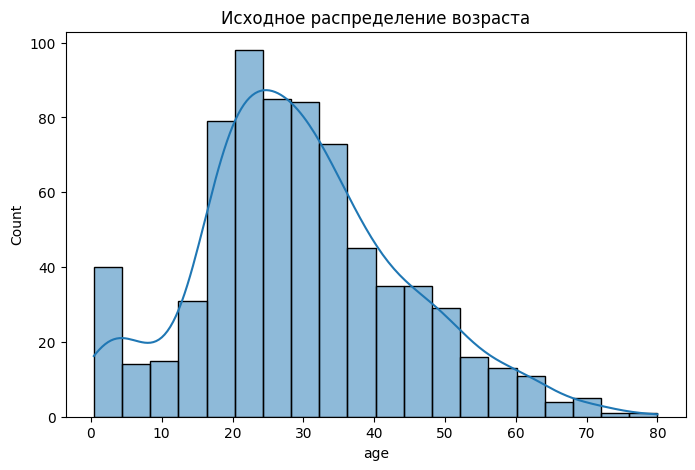

Статистика исходных данных:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64


In [ ]:
#распределение до заполнения:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title("Исходное распределение возраста")
plt.show()

print("Статистика исходных данных:")
print(df['age'].describe())

Гистограмма показывает исходное распределение возраста пассажиров.
Основная часть пассажиров находится в диапазоне примерно 15–40 лет.
В данных присутствуют пропуски, поэтому распределение построено только по известным значениям.

Заполнение пропусков Mean:

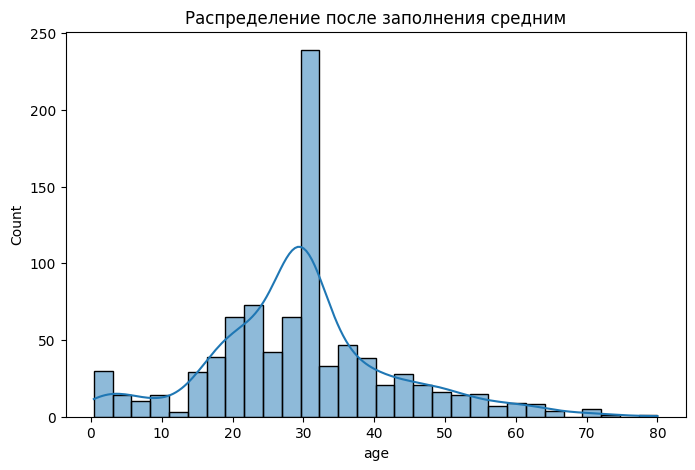

Статистика после Mean:
count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: age, dtype: float64


In [ ]:
df_mean = df.copy()

df_mean['age'] = df_mean['age'].fillna(df_mean['age'].mean())

plt.figure(figsize=(8,5))
sns.histplot(df_mean['age'], kde=True)
plt.title("Распределение после заполнения средним")
plt.show()

print("Статистика после Mean:")
print(df_mean['age'].describe())

После заполнения пропусков средним значением появляется заметный пик около среднего возраста.
Это происходит потому, что все пропущенные значения заменяются одним и тем же числом, что немного искажает форму распределения.

Заполнение Median

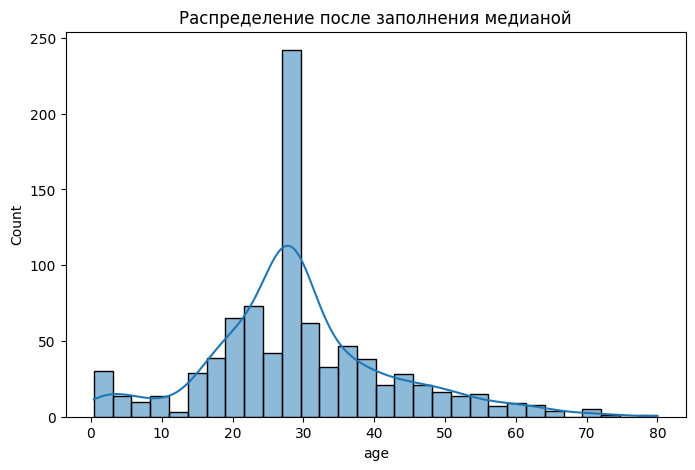

Статистика после Median:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64


In [ ]:
df_median = df.copy()

df_median['age'] = df_median['age'].fillna(df_median['age'].median())

plt.figure(figsize=(8,5))
sns.histplot(df_median['age'], kde=True)
plt.title("Распределение после заполнения медианой")
plt.show()

print("Статистика после Median:")
print(df_median['age'].describe())

Заполнение медианой также добавляет значения в центральную часть распределения,
но медиана менее чувствительна к выбросам, поэтому искажение распределения обычно меньше по сравнению со средним значением.

Как изменились среднее и стандартное отклонение:

In [ ]:
comparison = pd.DataFrame({
    "Method": ["Original", "Mean", "Median"],
    "Mean": [df['age'].mean(), df_mean['age'].mean(), df_median['age'].mean()],
    "Std": [df['age'].std(), df_mean['age'].std(), df_median['age'].std()]
})

comparison

,Method,Mean,Std
0,Original,29.699118,14.526497
1,Mean,29.699118,13.002015
2,Median,29.361582,13.019697


В ходе анализа были рассмотрены два метода заполнения
пропущенных значений в признаке age: средним значением
и медианой.
После заполнения средним значение среднего практически
не изменилось, однако стандартное отклонение уменьшилось,
так как большое количество значений стало равным среднему.
Заполнение медианой изменяет распределение меньше,
поскольку медиана устойчива к выбросам и не создаёт
искусственного пика в распределении.
Метод заполнения медианой меньше
искажает исходное распределение данных и является
предпочтительным для обработки пропусков в данном
датасете.

**ЗАДАНИЕ 2**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")

Выберем числовой признак "fare"

In [ ]:
df['fare'].describe()

,fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


Поиск выбросов методом IQR

In [ ]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['fare'] < lower_bound) | (df['fare'] > upper_bound)]

print("Количество выбросов (IQR):", len(outliers_iqr))

Количество выбросов (IQR): 116


Поиск выбросов методом Z-Score

In [ ]:
mean = df['fare'].mean()
std = df['fare'].std()

z_scores = (df['fare'] - mean) / std

outliers_z = df[np.abs(z_scores) > 3]

print("Количество выбросов (Z-score):", len(outliers_z))

Количество выбросов (Z-score): 20


Процент выбросов

In [ ]:
percent_iqr = len(outliers_iqr) / len(df) * 100
percent_z = len(outliers_z) / len(df) * 100

print("Процент выбросов IQR:", percent_iqr)
print("Процент выбросов Z-score:", percent_z)

Процент выбросов IQR: 13.019079685746352
Процент выбросов Z-score: 2.244668911335578


Визуализация Boxplot

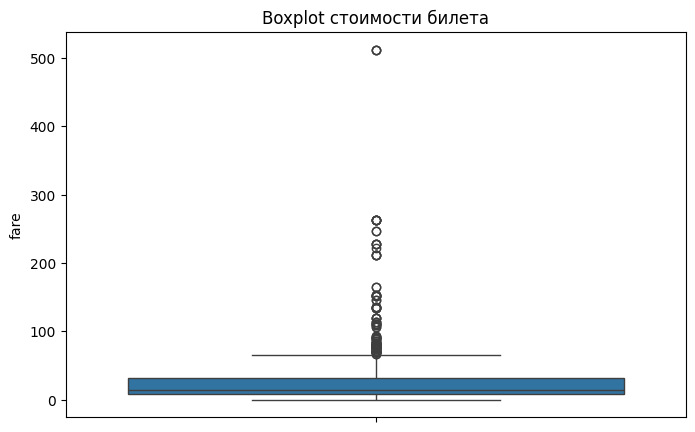

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['fare'])
plt.title("Boxplot стоимости билета")
plt.show()

На графике видно, что большинство значений стоимости билетов сосредоточено в нижней части распределения, однако присутствует небольшое количество очень дорогих билетов. Эти значения отображаются как отдельные точки и рассматриваются как потенциальные выбросы.

Scatterplot с выделением выбросов

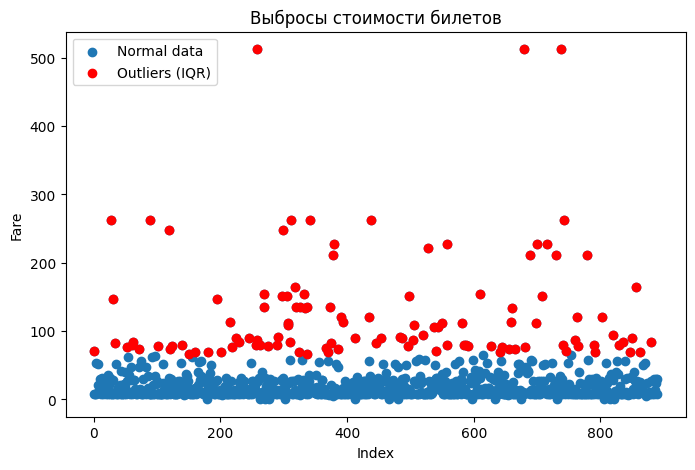

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df.index, df['fare'], label="Normal data")

plt.scatter(outliers_iqr.index,
            outliers_iqr['fare'],
            color='red',
            label="Outliers (IQR)")

plt.xlabel("Index")
plt.ylabel("Fare")
plt.title("Выбросы стоимости билетов")

plt.legend()
plt.show()

На scatterplot выбросы выделены красным цветом.
Видно, что некоторые билеты имеют значительно более высокую стоимость по сравнению с основной массой данных.

В ходе анализа были обнаружены выбросы в признаке fare (стоимость билета).
Метод IQR и метод Z-score показали наличие значений,
значительно превышающих основную массу данных.
Эти значения соответствуют пассажирам, купившим очень
дорогие билеты
Процент выбросов, найденных IQR, превышает 13%, удаление
этих строк может привести к потере важной информации
Следовательно, данные выбросы не являются ошибками
измерения и не требуют удаления.

**ЗАДАНИЕ 3**

Создание признака

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

# новый признак
df["FamilySize"] = df["sibsp"] + df["parch"] + 1

Корреляционная матрица

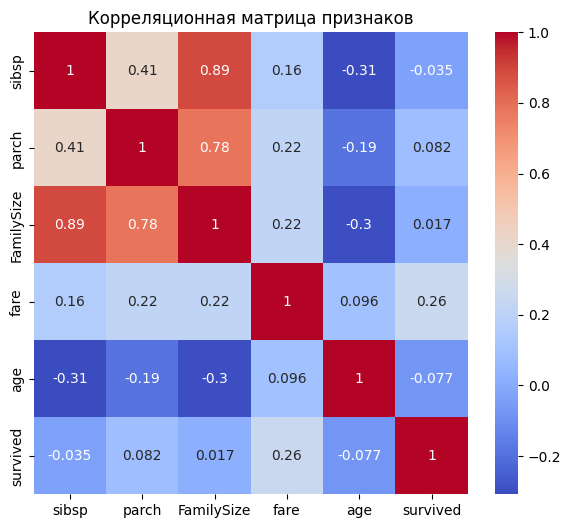

In [ ]:
corr = df[["sibsp","parch","FamilySize","fare","age","survived"]].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Корреляционная матрица признаков")
plt.show()

Корреляционная матрица показывает взаимосвязи между признаками.
Новый признак FamilySize имеет корреляцию с целевой переменной survived, что означает наличие статистической связи между размером семьи пассажира и вероятностью выживания.

Зависимость survived от familysize

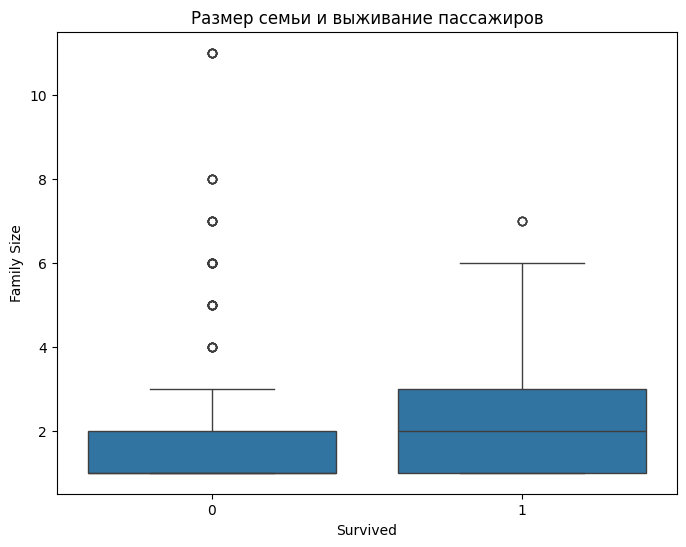

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x="survived", y="FamilySize", data=df)

plt.title("Размер семьи и выживание пассажиров")
plt.xlabel("Survived")
plt.ylabel("Family Size")

plt.show()

Корреляционная матрица показывает взаимосвязи между признаками.
Новый признак FamilySize имеет корреляцию с целевой переменной survived, что означает наличие статистической связи между размером семьи пассажира и вероятностью выживания.

В ходе анализа был создан новый признак FamilySize,
который отражает размер семьи пассажира.
Этот признак был получен на основе признаков sibsp
и parch, что имеет физический смысл, так как
пассажиры часто путешествовали семьями.
Анализ показал, что размер семьи влияет на вероятность выживания.
Пассажиры, путешествовавшие небольшими семьями в 2–4 человека, имели более высокую вероятность выживания по сравнению с одиночными пассажирами.
При очень больших размерах семьи вероятность выживания снова снижается.
Следовательно, признак FamilySize содержит полезную информацию и может быть использован в модели